In [21]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [22]:
data = pd.read_csv("synthetic_credit_card_fraud_dataset.csv")

In [23]:
data.head()

,user_id,card_number,expiry_date,cvv,same_billing_shipping,ip_risk_score,label,browser_Chrome,browser_Edge,browser_Firefox,browser_Safari,device_type_Desktop,device_type_Mobile,device_type_Tablet,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,U0001,4043321819600132,04/29,908,0,0.83,1,0,0,0,1,1,0,0,1,0,0,0
1,U0002,4379402654234,01/31,161,1,0.18,0,1,0,0,0,0,0,1,0,1,0,0
2,U0003,379407816184956,02/35,103,0,0.09,0,1,0,0,0,0,0,1,0,0,1,0
3,U0004,4316475255341928325,03/33,483,0,0.87,1,0,1,0,0,0,0,1,1,0,0,0
4,U0005,4030564139537675,09/27,238,1,0.72,1,1,0,0,0,0,1,0,0,0,0,1


In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2000 non-null   str    
 1   card_number            2000 non-null   int64  
 2   expiry_date            2000 non-null   str    
 3   cvv                    2000 non-null   int64  
 4   same_billing_shipping  2000 non-null   int64  
 5   ip_risk_score          2000 non-null   float64
 6   label                  2000 non-null   int64  
 7   browser_Chrome         2000 non-null   int64  
 8   browser_Edge           2000 non-null   int64  
 9   browser_Firefox        2000 non-null   int64  
 10  browser_Safari         2000 non-null   int64  
 11  device_type_Desktop    2000 non-null   int64  
 12  device_type_Mobile     2000 non-null   int64  
 13  device_type_Tablet     2000 non-null   int64  
 14  time_of_day_Afternoon  2000 non-null   int64  
 15  time_of_day_Eve

In [25]:
data.describe()

,card_number,cvv,same_billing_shipping,ip_risk_score,label,browser_Chrome,browser_Edge,browser_Firefox,browser_Safari,device_type_Desktop,device_type_Mobile,device_type_Tablet,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.054570e+17,833.293500,0.511500,0.499175,0.500000,0.25200,0.248500,0.242000,0.257500,0.329500,0.338000,0.332500,0.250000,0.258000,0.233000,0.259000
std,1.288763e+18,1423.779458,0.499993,0.358620,0.500125,0.43427,0.432251,0.428401,0.437366,0.470149,0.473147,0.471227,0.433121,0.437643,0.422848,0.438195
min,6.041475e+10,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.800367e+14,263.750000,0.000000,0.150000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.525345e+15,547.000000,1.000000,0.500000,0.500000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.620931e+15,799.250000,1.000000,0.850000,1.000000,1.00000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.250000,1.000000,0.000000,1.000000
max,4.996833e+18,9980.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
data.shape

(2000, 18)

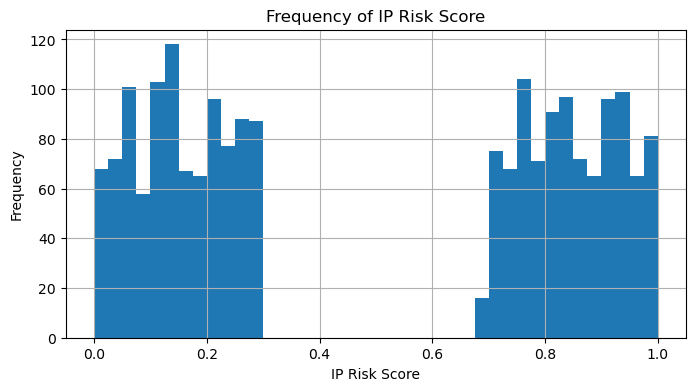

In [27]:
data['ip_risk_score'].hist(bins=40, figsize=(8, 4))
plt.xlabel("IP Risk Score")
plt.ylabel("Frequency")
plt.title("Frequency of IP Risk Score")
plt.show()

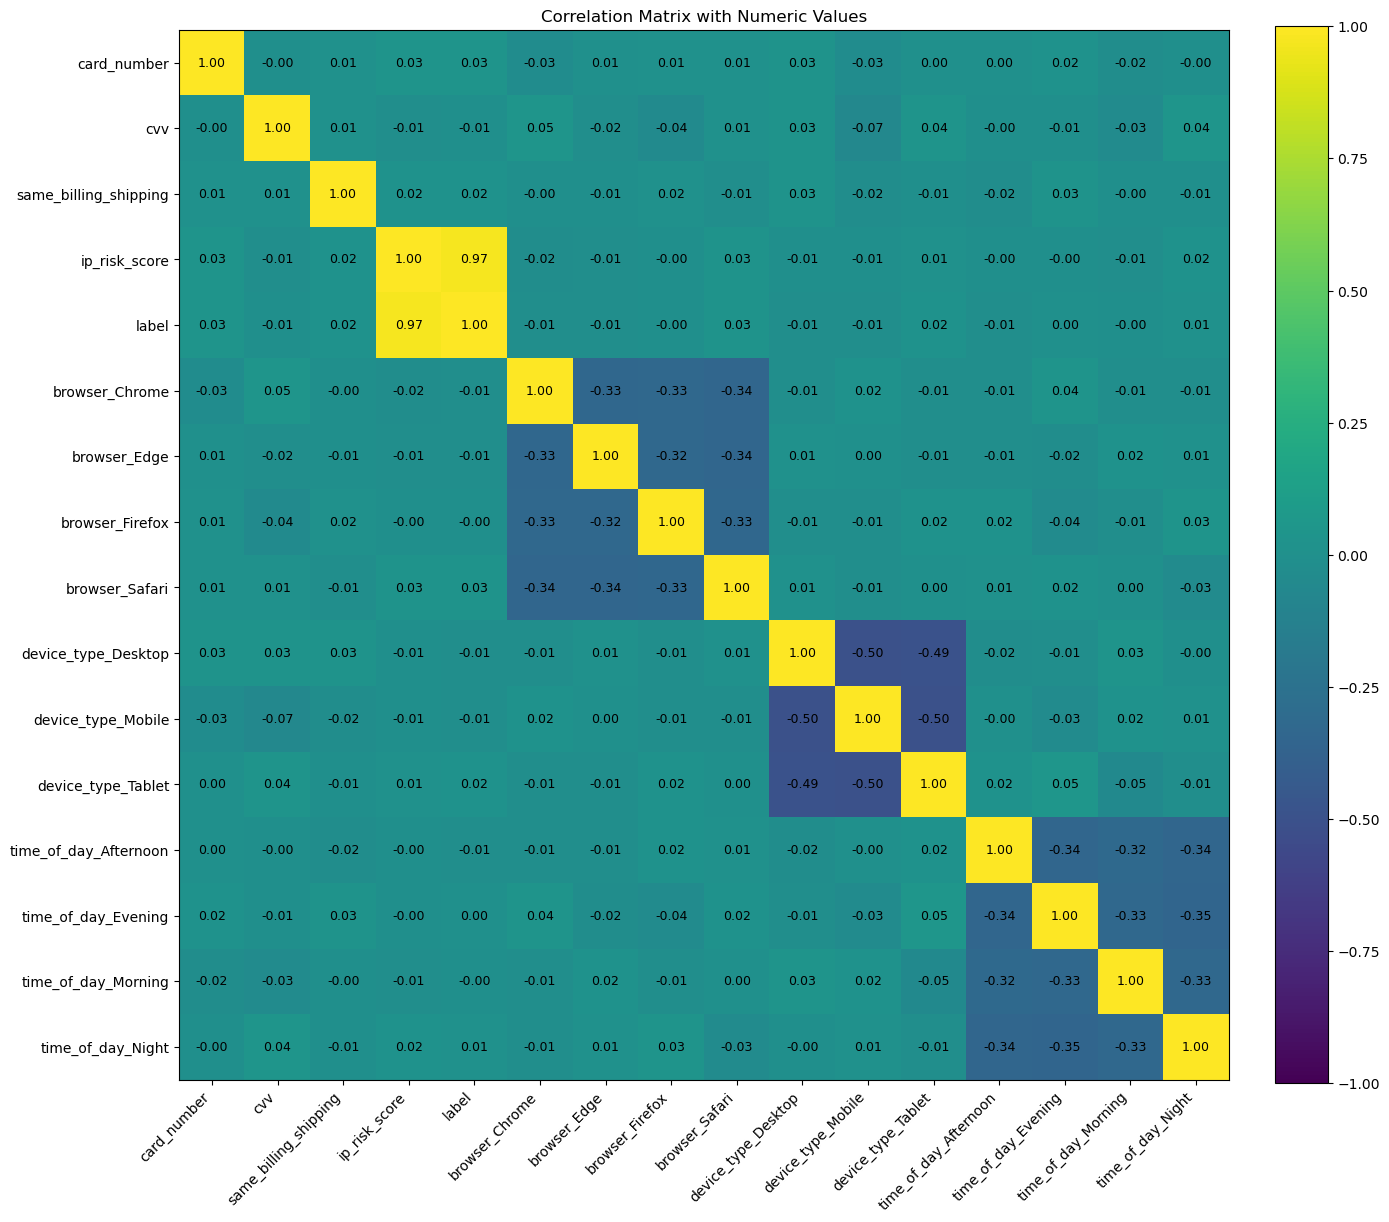

In [28]:
numeric_train = data.select_dtypes(include=[np.number])
corr_matrix = numeric_train.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Matrix with Numeric Values")
plt.tight_layout()
plt.show()

In [39]:
def preprocess_pipeline(data):
    X = data.drop(columns=['label','user_id', 'card_number', 'cvv','browser_Firefox', 'device_type_Desktop','time_of_day_Morning'])
    y = data["label"]

    
    dates = pd.to_datetime(data['expiry_date'], format='%m/%y')
    month = dates.dt.month
    year = dates.dt.year
    X["months_until_expiry"] = year + (month /12)
    X = X.drop(columns=['expiry_date'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train[['ip_risk_score', 'months_until_expiry']]= scaler.fit_transform(X_train[['ip_risk_score', 'months_until_expiry']])
    X_test[['ip_risk_score', 'months_until_expiry']]= scaler.transform(X_test[['ip_risk_score', 'months_until_expiry']])

    return X_train, X_test, y_train, y_test
        

In [40]:
preprocess_pipeline(data)

(      same_billing_shipping  ip_risk_score  browser_Chrome  browser_Edge  \
 946                       1       0.892294               0             1   
 976                       1       0.975962               0             0   
 1001                      0      -0.753163               0             1   
 1219                      1      -0.976275               1             0   
 1034                      1       0.780738               0             0   
 ...                     ...            ...             ...           ...   
 453                       1       0.892294               0             1   
 912                       1      -1.199388               0             1   
 468                       0       1.143296               0             1   
 579                       1       0.836516               0             0   
 1067                      0       1.059629               0             0   
 
       browser_Safari  device_type_Mobile  device_type_Tablet  \
 946     